# V44: LQ45 AI Strategy with Asymmetric Thresholds

**Objective**: Correct the AI's 'Over-Pessimism' by making it harder to exit the market and easier to re-enter.

### Modification (Asymmetric Logic):
Instead of a single threshold (0.60), we use separate thresholds for entering and exiting.

**New Logic:**
- **Entry Condition (Buy)**: IF `AI Prob >= 0.50` (Standard threshold).
- **Exit Condition (Sell)**: IF `AI Prob < 0.30` (Extreme Bearishness required) AND `Price < MA50`.

**Rationale**:
- This creates a 'Bias Long' strategy. We assume the market is bullish unless the AI is *extremely* confident (Prob < 0.30) that a crash is coming.
- This should drastically reduce 'Cash Days' and allow the portfolio to ride the bull run.

### Comparisons:
1. **AI Hybrid V44 (Asymmetric)**.
2. **Markowitz Static (Baseline)**.
3. **IHSG Proxy (Benchmark)**.


In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import os
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize
import xgboost as xgb
from sklearn.metrics import confusion_matrix
import warnings
warnings.filterwarnings('ignore')
plt.style.use('ggplot')

# --- 1. Load Data (LQ45) ---
file_path = 'data_lq45_2023_2025.xlsx'
if not os.path.exists(file_path):
    file_path = 'dataset_2023_2025.xlsx'

data = pd.read_excel(file_path, index_col=0, parse_dates=True)
returns = data.pct_change().dropna()
market_return = returns.mean(axis=1)
market_price = (1 + market_return).cumprod() * 100

print(f"Data Loaded: {len(data)} rows")


Data Loaded: 712 rows


In [2]:
# --- 2. Feature Engineering & AI Model ---

features = pd.DataFrame(index=returns.index)
features['Vol_20'] = market_return.rolling(window=20).std()
ma5 = market_price.rolling(window=5).mean()
ma20 = market_price.rolling(window=20).mean()
ma50 = market_price.rolling(window=50).mean()
features['Dist_MA20'] = market_price / ma20
features['Dist_MA50'] = market_price / ma50

# Calculate Trend Signal (Standard MA50)
trend_bullish = (market_price > ma50).astype(int)

# TARGET: MA Slope Direction
target = (ma5.shift(-1) > ma5).astype(int)

features = features.dropna()
target = target.reindex(features.index).fillna(0)
trend_bullish = trend_bullish.reindex(features.index).fillna(0)

train_mask = (features.index.year <= 2024)
test_mask = (features.index.year == 2025)

X_train, y_train = features.loc[train_mask], target.loc[train_mask]
X_test = features.loc[test_mask]

xgb_model = xgb.XGBClassifier(n_estimators=120, learning_rate=0.04, max_depth=6, random_state=42, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

print(f"[Strategy] Using Asymmetric Thresholds: Entry=0.50, Exit=0.30")


[Strategy] Using Asymmetric Thresholds: Entry=0.50, Exit=0.30


In [3]:
# --- 3. Simulation Logic (V44 Asymmetric) ---

def optimize_markowitz(selected_returns):
    if len(selected_returns.columns) == 0: return {}
    if len(selected_returns.columns) == 1: return {selected_returns.columns[0]: 1.0}
    mu, sigma = selected_returns.mean() * 252, selected_returns.cov() * 252
    sigma += np.eye(len(sigma)) * 1e-4 
    try:
        res = minimize(lambda w: -(np.sum(w*mu)/(np.sqrt(np.dot(w.T, np.dot(sigma, w))) + 1e-6)), 
                       [1./len(mu)]*len(mu), method='SLSQP', 
                       bounds=tuple((0, 1) for _ in range(len(mu))), 
                       constraints=({'type': 'eq', 'fun': lambda x: np.sum(x) - 1}))
        return dict(zip(selected_returns.columns, res.x)) if res.success else {}
    except:
        return {}

def run_simulation_asymmetric(strategy_type, test_dates, returns, ai_probs=None, trend_signal=None, fee=0.0025):
    val, history, dates = 100.0, [100.0], [test_dates[0]]
    prev_weights = {}
    static_weights = None
    prev_state = "Invested" # Default start
    state_history = []
    
    # Thresholds
    THRESH_ENTRY = 0.50
    THRESH_EXIT = 0.30
    
    for i, date in enumerate(test_dates[:-1]):
        loc_idx = returns.index.get_loc(date)
        window_rets = returns.iloc[loc_idx-30:loc_idx]
        
        weights = {}
        current_state = prev_state

        if strategy_type == 'AI Hybrid V44':
            prob = ai_probs.loc[date]
            is_trend_up = trend_signal.loc[date] == 1
            
            # Logic V44: State Machine
            if prev_state == "Invested":
                # Only exit if EXTREME Bearishness AND Trend Broken
                if (prob < THRESH_EXIT) and (not is_trend_up):
                    current_state = "Cash"
            elif prev_state == "Cash":
                # Re-enter if Neutral/Bullish OR Trend Restored
                if (prob >= THRESH_ENTRY) or (is_trend_up):
                    current_state = "Invested"
            
            if current_state == "Cash":
                weights = {'CASH': 1.0}
            else:
                valid_assets = window_rets.dropna(axis=1, how='any').columns
                weights = optimize_markowitz(window_rets[valid_assets])
                
        elif strategy_type == 'Markowitz Static':
            if static_weights is None:
                valid_assets = window_rets.dropna(axis=1, how='any').columns
                static_weights = optimize_markowitz(window_rets[valid_assets])
            weights = static_weights
            current_state = "Static"
        
        state_history.append(current_state)
        
        # Transaction Costs
        all_assets = set(list(weights.keys()) + list(prev_weights.keys()))
        turnover = sum(abs(weights.get(a, 0) - prev_weights.get(a, 0)) for a in all_assets)
        val -= (val * turnover * fee)
        
        next_date = test_dates[i+1]
        day_ret = 0 if 'CASH' in weights else sum(w * returns.loc[next_date, a] for a, w in weights.items())
        val *= (1 + day_ret)
        history.append(val); dates.append(next_date); prev_weights = weights
        prev_state = current_state
        
    return pd.DataFrame({'Portfolio_Value': history, 'State': state_history + [state_history[-1]]}, index=dates)


In [4]:
# --- 4. Models & Benchmark Execution ---
ai_probs = pd.Series(xgb_model.predict_proba(X_test)[:, 1], index=X_test.index)
test_trend = trend_bullish.loc[X_test.index]

print("Running AI Hybrid V44 (Asymmetric)...")
hybrid_res_v44 = run_simulation_asymmetric('AI Hybrid V44', X_test.index, returns, ai_probs, test_trend)

print("Running Markowitz Static...")
static_res = run_simulation_asymmetric('Markowitz Static', X_test.index, returns)

print("Calculating IHSG Benchmark...")
ihsg_ret = market_return.loc[X_test.index]
ihsg_price = (1 + ihsg_ret).cumprod() * 100


Running AI Hybrid V44 (Asymmetric)...
Running Markowitz Static...
Calculating IHSG Benchmark...


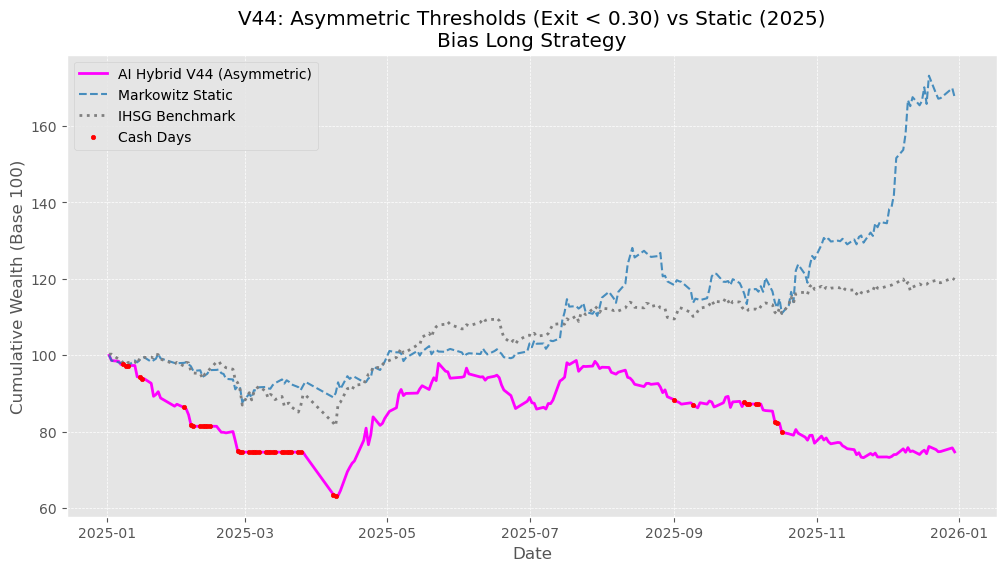

Total Days in Cash: 45 (Strategy forced to stay invested)


In [5]:
# --- Visualization: Performance Comparison ---
plt.figure(figsize=(12, 6))
plt.plot(hybrid_res_v44['Portfolio_Value'], label=f'AI Hybrid V44 (Asymmetric)', color='magenta', linewidth=2)
plt.plot(static_res['Portfolio_Value'], label='Markowitz Static', color='#1f77b4', linestyle='--', alpha=0.8)
plt.plot(ihsg_price, label='IHSG Benchmark', color='#7f7f7f', linestyle=':', linewidth=2)

# Highlight Cash Days
regime_switches = hybrid_res_v44[hybrid_res_v44['State'].str.contains('Cash')]
if not regime_switches.empty:
    plt.scatter(regime_switches.index, regime_switches['Portfolio_Value'], color='red', s=10, label='Cash Days', zorder=5)

plt.title(f'V44: Asymmetric Thresholds (Exit < 0.30) vs Static (2025)\nBias Long Strategy')
plt.ylabel('Cumulative Wealth (Base 100)')
plt.xlabel('Date')
plt.legend(loc='upper left')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.savefig('v44_asymmetric_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# Stats
cash_days = hybrid_res_v44['State'].value_counts().get('Cash', 0)
print(f"Total Days in Cash: {cash_days} (Strategy forced to stay invested)")
